In [1]:
!pip install transformers accelerate bitsandbytes Pillow pandas matplotlib -q
print('Зависимости установлены')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 20.9 MB/s eta 0:00:00
Зависимости установлены


In [2]:
import os, json, time, requests, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO
import torch
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('GPU не найден! Зайди: Среда выполнения → Сменить среду → T4 GPU')

GPU: Tesla T4
VRAM: 15.6 GB


Mounted at /content/drive
Обложек скачано: 40/50


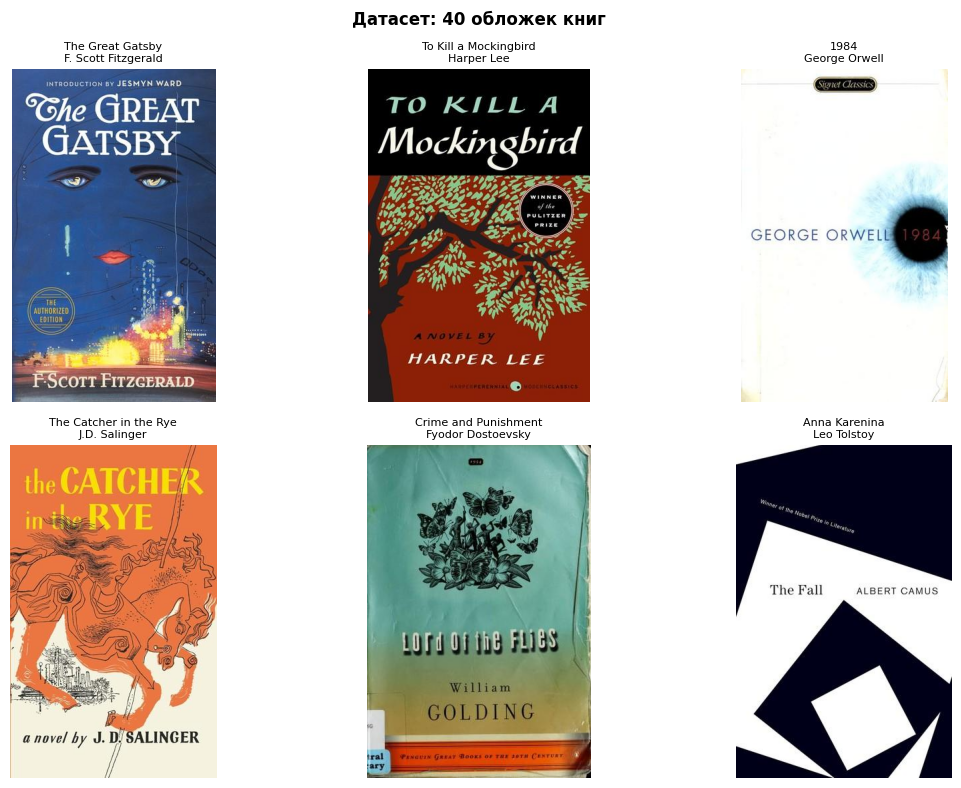

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE = '/content/drive/MyDrive/lab3_books'
os.makedirs(f'{DRIVE_BASE}/covers', exist_ok=True)

BLIP2_PATH = f'{DRIVE_BASE}/blip2_results.json'
LLAVA_PATH = f'{DRIVE_BASE}/llava_results.json'

BOOKS = [
    {'isbn': '9780743273565', 'title': 'The Great Gatsby',             'author': 'F. Scott Fitzgerald',   'genre': 'Classic'},
    {'isbn': '9780061120084', 'title': 'To Kill a Mockingbird',        'author': 'Harper Lee',            'genre': 'Classic'},
    {'isbn': '9780451524935', 'title': '1984',                         'author': 'George Orwell',         'genre': 'Dystopia'},
    {'isbn': '9780316769174', 'title': 'The Catcher in the Rye',       'author': 'J.D. Salinger',         'genre': 'Classic'},
    {'isbn': '9780140283334', 'title': 'Crime and Punishment',         'author': 'Fyodor Dostoevsky',    'genre': 'Classic'},
    {'isbn': '9780061965487', 'title': 'Brave New World',              'author': 'Aldous Huxley',        'genre': 'Dystopia'},
    {'isbn': '9780679720225', 'title': 'Anna Karenina',                'author': 'Leo Tolstoy',          'genre': 'Classic'},
    {'isbn': '9780486282114', 'title': 'Moby Dick',                    'author': 'Herman Melville',      'genre': 'Classic'},
    {'isbn': '9780141439556', 'title': 'Great Expectations',           'author': 'Charles Dickens',      'genre': 'Classic'},
    {'isbn': '9780374528379', 'title': 'Madame Bovary',                'author': 'Gustave Flaubert',     'genre': 'Classic'},
    {'isbn': '9780618640157', 'title': 'The Lord of the Rings',        'author': 'J.R.R. Tolkien',       'genre': 'Fantasy'},
    {'isbn': '9780439708180', 'title': 'Harry Potter Sorcerers Stone', 'author': 'J.K. Rowling',         'genre': 'Fantasy'},
    {'isbn': '9780812981605', 'title': 'The Name of the Wind',         'author': 'Patrick Rothfuss',     'genre': 'Fantasy'},
    {'isbn': '9780553588484', 'title': 'A Game of Thrones',            'author': 'George R.R. Martin',   'genre': 'Fantasy'},
    {'isbn': '9780385490818', 'title': 'The Handmaid Tale',            'author': 'Margaret Atwood',      'genre': 'Dystopia'},
    {'isbn': '9780062409850', 'title': 'The Martian',                  'author': 'Andy Weir',            'genre': 'Sci-Fi'},
    {'isbn': '9780385472579', 'title': 'Dune',                         'author': 'Frank Herbert',        'genre': 'Sci-Fi'},
    {'isbn': '9780441013593', 'title': 'Neuromancer',                  'author': 'William Gibson',       'genre': 'Sci-Fi'},
    {'isbn': '9780062073488', 'title': 'The Hunger Games',             'author': 'Suzanne Collins',      'genre': 'Dystopia'},
    {'isbn': '9780062409867', 'title': 'Project Hail Mary',            'author': 'Andy Weir',            'genre': 'Sci-Fi'},
    {'isbn': '9780316346627', 'title': 'Gone Girl',                    'author': 'Gillian Flynn',        'genre': 'Thriller'},
    {'isbn': '9780385337953', 'title': 'The Da Vinci Code',            'author': 'Dan Brown',            'genre': 'Thriller'},
    {'isbn': '9781250301697', 'title': 'The Silent Patient',           'author': 'Alex Michaelides',     'genre': 'Thriller'},
    {'isbn': '9781250301680', 'title': 'The Thursday Murder Club',     'author': 'Richard Osman',        'genre': 'Mystery'},
    {'isbn': '9780307277671', 'title': 'No Country for Old Men',       'author': 'Cormac McCarthy',      'genre': 'Thriller'},
    {'isbn': '9780062316097', 'title': 'The Alchemist',                'author': 'Paulo Coelho',         'genre': 'Fiction'},
    {'isbn': '9781594631931', 'title': 'The Kite Runner',              'author': 'Khaled Hosseini',      'genre': 'Fiction'},
    {'isbn': '9780735224292', 'title': 'Little Fires Everywhere',      'author': 'Celeste Ng',           'genre': 'Fiction'},
    {'isbn': '9781250778833', 'title': 'The Midnight Library',         'author': 'Matt Haig',            'genre': 'Fiction'},
    {'isbn': '9780735211292', 'title': 'Where the Crawdads Sing',      'author': 'Delia Owens',          'genre': 'Fiction'},
    {'isbn': '9780374202601', 'title': 'The Road',                     'author': 'Cormac McCarthy',      'genre': 'Fiction'},
    {'isbn': '9780525559474', 'title': 'Normal People',                'author': 'Sally Rooney',         'genre': 'Fiction'},
    {'isbn': '9780385737951', 'title': 'The Fault in Our Stars',       'author': 'John Green',           'genre': 'Young Adult'},
    {'isbn': '9780140268867', 'title': '100 Years of Solitude',        'author': 'G. Garcia Marquez',    'genre': 'Fiction'},
    {'isbn': '9780385490436', 'title': 'Beloved',                      'author': 'Toni Morrison',        'genre': 'Fiction'},
    {'isbn': '9780525559498', 'title': 'Sapiens',                      'author': 'Yuval Noah Harari',    'genre': 'Non-Fiction'},
    {'isbn': '9780062409874', 'title': 'Thinking Fast and Slow',       'author': 'Daniel Kahneman',      'genre': 'Non-Fiction'},
    {'isbn': '9781501156700', 'title': 'Atomic Habits',                'author': 'James Clear',          'genre': 'Self-Help'},
    {'isbn': '9780062316134', 'title': 'Outliers',                     'author': 'Malcolm Gladwell',     'genre': 'Non-Fiction'},
    {'isbn': '9780062316110', 'title': 'The Power of Habit',           'author': 'Charles Duhigg',       'genre': 'Non-Fiction'},
    {'isbn': '9780062979988', 'title': 'Educated',                     'author': 'Tara Westover',        'genre': 'Memoir'},
    {'isbn': '9780525520405', 'title': 'Becoming',                     'author': 'Michelle Obama',       'genre': 'Memoir'},
    {'isbn': '9781476746586', 'title': 'Gone with the Wind',           'author': 'Margaret Mitchell',    'genre': 'Historical'},
    {'isbn': '9780679642428', 'title': 'Ulysses',                      'author': 'James Joyce',          'genre': 'Modernism'},
    {'isbn': '9780141441146', 'title': 'Middlemarch',                  'author': 'George Eliot',         'genre': 'Classic'},
    {'isbn': '9780743477109', 'title': 'Romeo and Juliet',             'author': 'William Shakespeare',  'genre': 'Classic Drama'},
    {'isbn': '9780062316158', 'title': 'The Tipping Point',            'author': 'Malcolm Gladwell',     'genre': 'Non-Fiction'},
    {'isbn': '9780679720201', 'title': 'In Search of Lost Time',       'author': 'Marcel Proust',        'genre': 'Classic'},
    {'isbn': '9780316346610', 'title': 'Dark Places',                  'author': 'Gillian Flynn',        'genre': 'Thriller'},
    {'isbn': '9780385490817', 'title': 'The Blind Assassin',           'author': 'Margaret Atwood',      'genre': 'Fiction'},
]

# Скачиваем обложки
downloaded = []
for book in BOOKS:
    path = f'{DRIVE_BASE}/covers/{book["isbn"]}.jpg'
    if os.path.exists(path):
        downloaded.append({**book, 'path': path})
        continue
    try:
        url  = f'https://covers.openlibrary.org/b/isbn/{book["isbn"]}-L.jpg'
        resp = requests.get(url, timeout=10)
        if resp.status_code == 200 and len(resp.content) > 5000:
            img = Image.open(BytesIO(resp.content))
            if img.size[0] > 50:
                img.save(path)
                downloaded.append({**book, 'path': path})
    except Exception:
        pass
    time.sleep(0.3)

print(f'Обложек скачано: {len(downloaded)}/{len(BOOKS)}')

# Превью
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    if i < len(downloaded):
        ax.imshow(Image.open(downloaded[i]['path']))
        ax.set_title(f"{downloaded[i]['title']}\n{downloaded[i]['author']}", fontsize=8)
    ax.axis('off')
plt.suptitle(f'Датасет: {len(downloaded)} обложек книг', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/dataset_preview.png', dpi=100, bbox_inches='tight')
plt.show()

In [4]:
from transformers import Blip2Processor, Blip2ForConditionalGeneration

print('Загружаем BLIP-2 (~3 ГБ)...')
t0 = time.time()

blip2_processor = Blip2Processor.from_pretrained('Salesforce/blip2-opt-2.7b')
blip2_model     = Blip2ForConditionalGeneration.from_pretrained(
    'Salesforce/blip2-opt-2.7b',
    torch_dtype=torch.float16,
    device_map='auto'
).eval()

print(f'BLIP-2 загружен за {(time.time()-t0)/60:.1f} мин')
print(f'VRAM: {torch.cuda.memory_allocated()/1e9:.1f} ГБ')


def blip2_ask(image, question, max_new_tokens=80):
    """Задаёт вопрос по изображению через BLIP-2."""
    prompt = f'Question: {question} Answer:'
    inputs = blip2_processor(
        images=image, text=prompt, return_tensors='pt'
    ).to(DEVICE, torch.float16)
    with torch.no_grad():
        out = blip2_model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    text = blip2_processor.decode(out[0], skip_special_tokens=True).strip()
    # убираем повтор вопроса если есть
    if 'Answer:' in text:
        text = text.split('Answer:')[-1].strip()
    return text


# Тест
test_img = Image.open(downloaded[0]['path']).convert('RGB')
print(f'\nТест на "{downloaded[0]["title"]}":')
print(f'  Цвета: {blip2_ask(test_img, "What are the main colors on this book cover?")}')
print(f'  Стиль: {blip2_ask(test_img, "How would you describe the visual style of this cover?")}')

Загружаем BLIP-2 (~3 ГБ)...


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/122k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

BLIP-2 загружен за 3.5 мин
VRAM: 7.7 ГБ

Тест на "The Great Gatsby":
  Цвета: blue, green, red, and yellow
  Стиль: The Great Gatsby


In [5]:
QUESTIONS = {
    'cover_colors':    'What are the main colors on this book cover?',
    'cover_style':     'How would you describe the visual style of this book cover?',
    'mood':            'What mood or atmosphere does this book cover convey?',
    'visual_elements': 'What illustrations or visual elements are on this book cover?',
    'target_audience': 'Who is the target audience for this book based on the cover?',
}


def generate_blip2(book):
    """Генерирует описание книги через BLIP-2 — серия вопросов."""
    img = Image.open(book['path']).convert('RGB')
    attrs = {key: blip2_ask(img, q) for key, q in QUESTIONS.items()}
    return {
        'isbn':          book['isbn'],
        'title':         book['title'],
        'author':        book['author'],
        'genre_gt':      book['genre'],
        'model':         'BLIP-2',
        **attrs,
        'marketing_text': (
            f"{book['title']} by {book['author']} — "
            f"a captivating {book['genre'].lower()} book. "
            f"The cover features {attrs['visual_elements'].lower()}, "
            f"conveying {attrs['mood'].lower()}. "
            f"Perfect for {attrs['target_audience'].lower()}."
        )
    }


# Загружаем существующие результаты
blip2_results = json.load(open(BLIP2_PATH)) if os.path.exists(BLIP2_PATH) else []
done_isbns    = {r['isbn'] for r in blip2_results}
todo          = [b for b in downloaded if b['isbn'] not in done_isbns]

print(f'BLIP-2: уже готово {len(blip2_results)}, осталось {len(todo)}')
t0 = time.time()

for i, book in enumerate(todo):
    try:
        blip2_results.append(generate_blip2(book))
        with open(BLIP2_PATH, 'w', encoding='utf-8') as f:
            json.dump(blip2_results, f, ensure_ascii=False, indent=2)
    except Exception as e:
        print(f'  Ошибка {book["title"]}: {e}')
    if (i + 1) % 10 == 0:
        print(f'  {i+1}/{len(todo)} | {time.time()-t0:.0f}с')

print(f'\nBLIP-2 завершён: {len(blip2_results)} книг за {(time.time()-t0)/60:.1f} мин')

BLIP-2: уже готово 0, осталось 40
  10/40 | 16с
  20/40 | 44с
  30/40 | 67с
  40/40 | 97с

BLIP-2 завершён: 40 книг за 1.6 мин


In [11]:
from transformers import AutoProcessor, LlavaForConditionalGeneration
import gc, torch

# Удаляем неправильно загруженную модель
del llava_model, llava_processor
torch.cuda.empty_cache()
gc.collect()
print(f'VRAM после очистки: {torch.cuda.memory_allocated()/1e9:.1f} ГБ')

# Загружаем с правильным классом для llava-1.5
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16,
)

print('Загружаем LLaVA-1.5-7B с правильным процессором...')
t0 = time.time()

llava_processor = AutoProcessor.from_pretrained('llava-hf/llava-1.5-7b-hf')
llava_model     = LlavaForConditionalGeneration.from_pretrained(
    'llava-hf/llava-1.5-7b-hf',
    quantization_config=bnb_config,
    device_map='auto'
).eval()

print(f'Загружена за {(time.time()-t0)/60:.1f} мин')
print(f'VRAM: {torch.cuda.memory_allocated()/1e9:.1f} ГБ')

def llava_generate(image, prompt, max_new_tokens=300):
    """Генерирует текст через LLaVA-1.5 с правильным форматом."""
    # LLaVA-1.5 использует формат USER: <image>\n{prompt} ASSISTANT:
    full_prompt = f'USER: <image>\n{prompt} ASSISTANT:'
    inputs = llava_processor(
        images=image,
        text=full_prompt,
        return_tensors='pt'
    ).to(DEVICE)

    with torch.no_grad():
        out = llava_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    new_tokens = out[0][inputs['input_ids'].shape[1]:]
    return llava_processor.decode(new_tokens, skip_special_tokens=True).strip()

# Тест
test_img = Image.open(downloaded[0]['path']).convert('RGB')
test_out = llava_generate(test_img, 'Briefly describe this book cover.')
print(f'\nТест: {test_out[:150]}')

VRAM после очистки: 0.0 ГБ
Загружаем LLaVA-1.5-7B с правильным процессором...


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

Загружена за 1.1 мин
VRAM: 4.4 ГБ

Тест: The book cover features a close-up of a woman's face, with her eyes and mouth prominently displayed. The image is set against a blue background, and t


In [12]:
LLAVA_PROMPT = (
    'Analyze this book cover and provide:\n'
    '1. Main colors on the cover\n'
    '2. Visual style (minimalist/illustrative/photographic/typographic/etc)\n'
    '3. Mood and atmosphere\n'
    '4. Key visual elements and illustrations\n'
    '5. Target audience\n'
    'Be concise, one sentence per item.'
)


def parse_llava_response(raw):
    """Парсит нумерованный список из ответа LLaVA."""
    keys   = ['cover_colors', 'cover_style', 'mood', 'visual_elements', 'target_audience']
    result = {k: '' for k in keys}
    for line in raw.split('\n'):
        line = line.strip()
        for idx, key in enumerate(keys, start=1):
            if line.startswith(f'{idx}.'):
                result[key] = line[2:].strip()
    if not any(result.values()):
        result['cover_style'] = raw[:200]
    return result


def generate_llava(book):
    """Генерирует описание книги через LLaVA — один развёрнутый prompt."""
    img   = Image.open(book['path']).convert('RGB')
    raw   = llava_generate(img, LLAVA_PROMPT)
    attrs = parse_llava_response(raw)
    return {
        'isbn':     book['isbn'],
        'title':    book['title'],
        'author':   book['author'],
        'genre_gt': book['genre'],
        'model':    'LLaVA-1.5-7B',
        **attrs,
        'marketing_text': (
            f"{book['title']} by {book['author']} — "
            f"a compelling {book['genre'].lower()} read. "
            f"{attrs['mood']}. "
            f"Ideal for {attrs['target_audience']}."
        ),
        'raw': raw
    }


llava_results = json.load(open(LLAVA_PATH)) if os.path.exists(LLAVA_PATH) else []
done_isbns    = {r['isbn'] for r in llava_results}
todo          = [b for b in downloaded if b['isbn'] not in done_isbns]

print(f'LLaVA: уже готово {len(llava_results)}, осталось {len(todo)}')
t0 = time.time()

for i, book in enumerate(todo):
    try:
        llava_results.append(generate_llava(book))
        with open(LLAVA_PATH, 'w', encoding='utf-8') as f:
            json.dump(llava_results, f, ensure_ascii=False, indent=2)
    except Exception as e:
        print(f'  Ошибка {book["title"]}: {e}')
    if (i + 1) % 10 == 0:
        print(f'  {i+1}/{len(todo)} | {time.time()-t0:.0f}с')

print(f'\nLLaVA: {len(llava_results)} книг за {(time.time()-t0)/60:.1f} мин')

LLaVA: уже готово 0, осталось 40
  10/40 | 29с
  20/40 | 54с
  30/40 | 80с
  40/40 | 105с

LLaVA: 40 книг за 1.8 мин


In [13]:
def auto_assess(r):
    """Оценка качества описания по 4 критериям (0-1)."""
    fields  = ['cover_colors', 'cover_style', 'mood', 'visual_elements', 'target_audience']
    filled  = sum(1 for f in fields if r.get(f) and len(str(r[f])) > 10)
    total_c = sum(len(str(r.get(f, ''))) for f in fields)
    mkt     = str(r.get('marketing_text', ''))
    text    = ' '.join(str(v) for v in r.values()).lower()
    generic = ['book', 'cover', 'image', 'shows', 'features', 'picture', 'appears']
    return {
        'полнота':       filled / len(fields),
        'детальность':   min(total_c / 400, 1.0),
        'маркетинг':     min(len(mkt) / 150, 1.0),
        'специфичность': max(0, 1.0 - sum(text.count(w) for w in generic) / 8),
    }


all_results = blip2_results + llava_results
scores_list = [auto_assess(r) for r in all_results]
df_results  = pd.DataFrame(all_results)
df_scores   = pd.DataFrame(scores_list)
df_scores['итого'] = df_scores.mean(axis=1)
df_full     = pd.concat([df_results.reset_index(drop=True),
                          df_scores.reset_index(drop=True)], axis=1)

print('=' * 60)
print('АВТОМАТИЧЕСКАЯ ОЦЕНКА')
print('=' * 60)
for name in ['BLIP-2', 'LLaVA-1.5-7B']:
    mask = df_full['model'] == name
    if mask.sum() == 0:
        continue
    print(f'\n{name} ({mask.sum()} книг):')
    for m in ['полнота', 'детальность', 'маркетинг', 'специфичность', 'итого']:
        v   = df_full.loc[mask, m].mean()
        bar = '█' * int(v * 20)
        print(f'  {m:<15} {v:.3f}  {bar}')
print('=' * 60)

АВТОМАТИЧЕСКАЯ ОЦЕНКА

BLIP-2 (40 книг):
  полнота         0.750  ███████████████
  детальность     0.446  ████████
  маркетинг       0.992  ███████████████████
  специфичность   0.234  ████
  итого           0.605  ████████████

LLaVA-1.5-7B (40 книг):
  полнота         0.200  ████
  детальность     0.233  ████
  маркетинг       0.512  ██████████
  специфичность   0.325  ██████
  итого           0.318  ██████


In [15]:
import os, json
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE    = '/content/drive/MyDrive/lab3_books'
BLIP2_PATH    = f'{DRIVE_BASE}/blip2_results.json'
LLAVA_PATH    = f'{DRIVE_BASE}/llava_results.json'
ASSESSOR_PATH = f'{DRIVE_BASE}/assessor_scores.json'

# Загружаем результаты с Drive
blip2_results = json.load(open(BLIP2_PATH)) if os.path.exists(BLIP2_PATH) else []
llava_results = json.load(open(LLAVA_PATH)) if os.path.exists(LLAVA_PATH) else []

print(f'BLIP-2 результатов: {len(blip2_results)}')
print(f'LLaVA результатов:  {len(llava_results)}')

# Восстанавливаем список скачанных книг
COVERS_DIR = f'{DRIVE_BASE}/covers'
downloaded = []
for fname in sorted(os.listdir(COVERS_DIR)):
    if fname.endswith('.jpg'):
        isbn = fname.replace('.jpg', '')
        # ищем метаданные в результатах
        meta = next((r for r in blip2_results + llava_results if r['isbn'] == isbn), None)
        if meta:
            downloaded.append({
                'isbn':   isbn,
                'title':  meta.get('title', isbn),
                'author': meta.get('author', ''),
                'genre':  meta.get('genre_gt', ''),
                'path':   f'{COVERS_DIR}/{fname}'
            })

print(f'Обложек найдено: {len(downloaded)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BLIP-2 результатов: 40
LLaVA результатов:  40
Обложек найдено: 40


Книг для оценки: 10
Показываем обложки и описания...



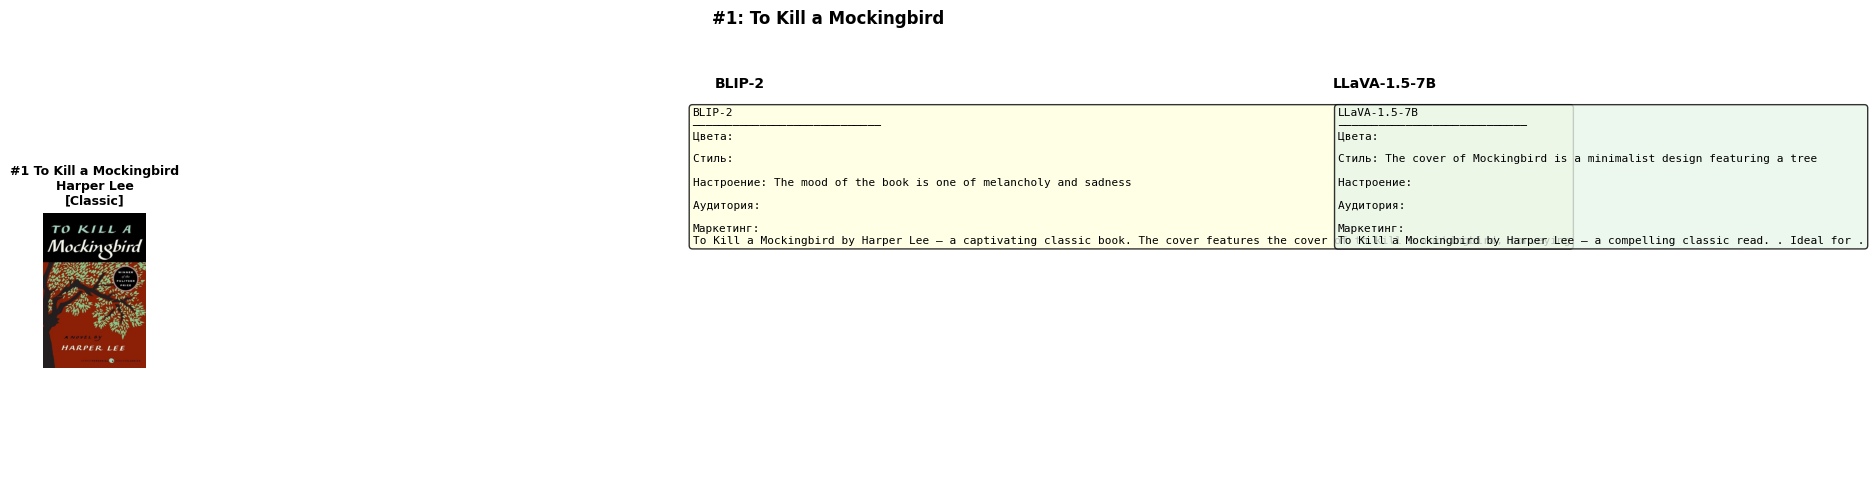

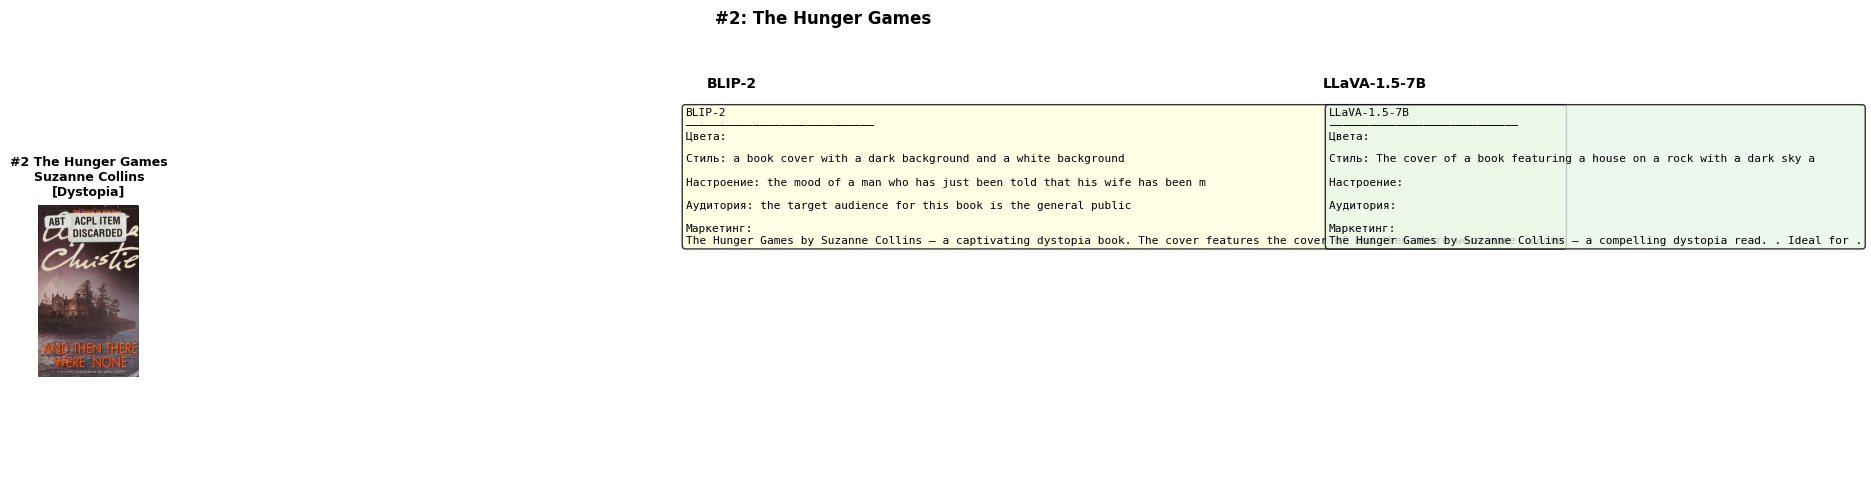

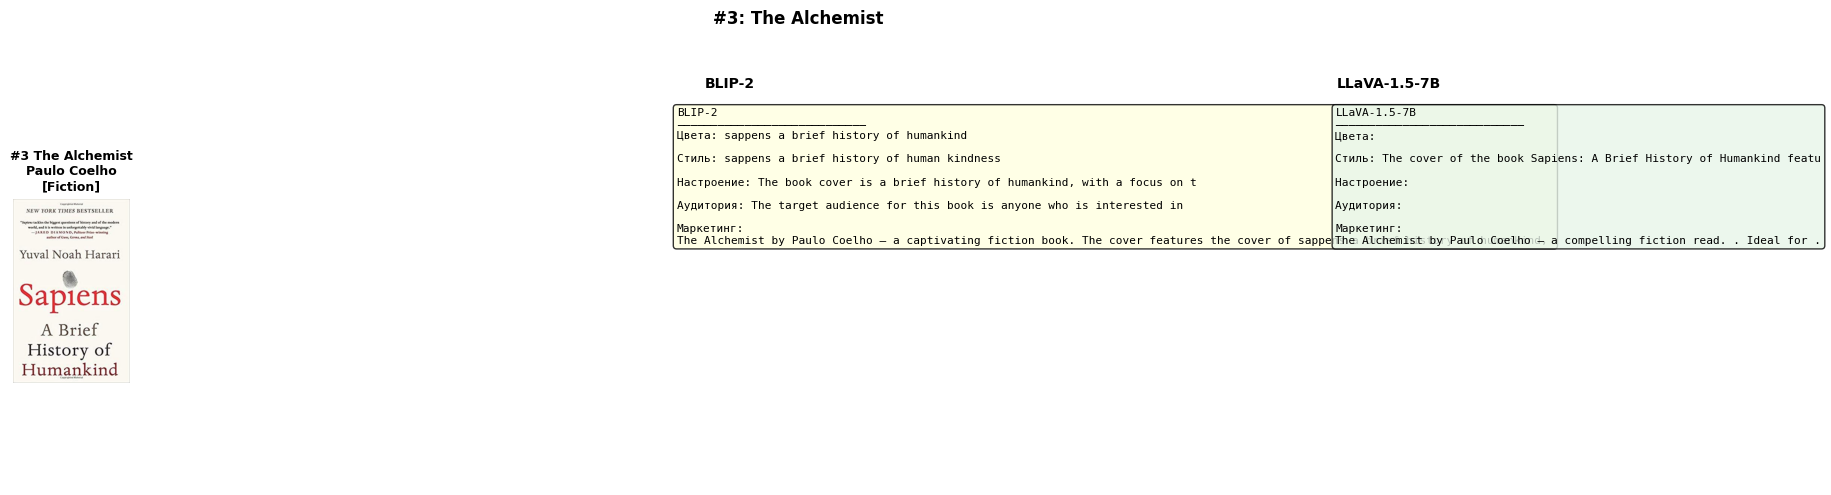

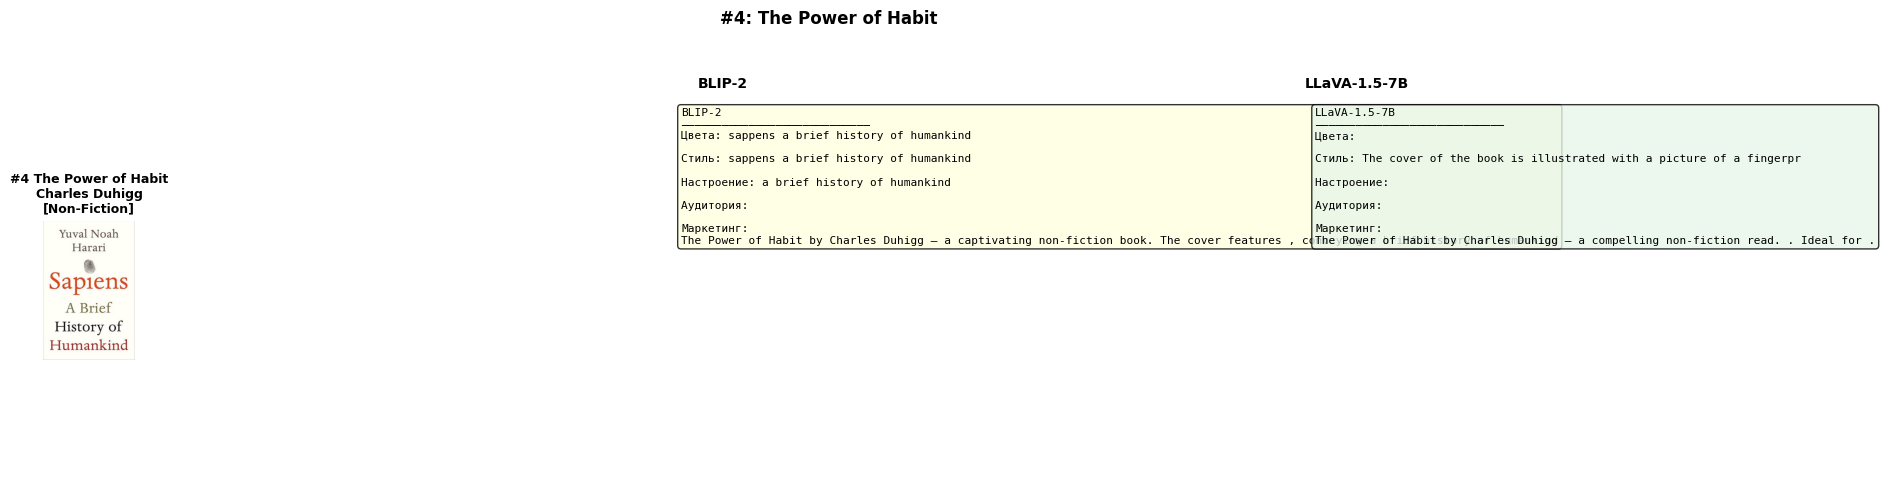

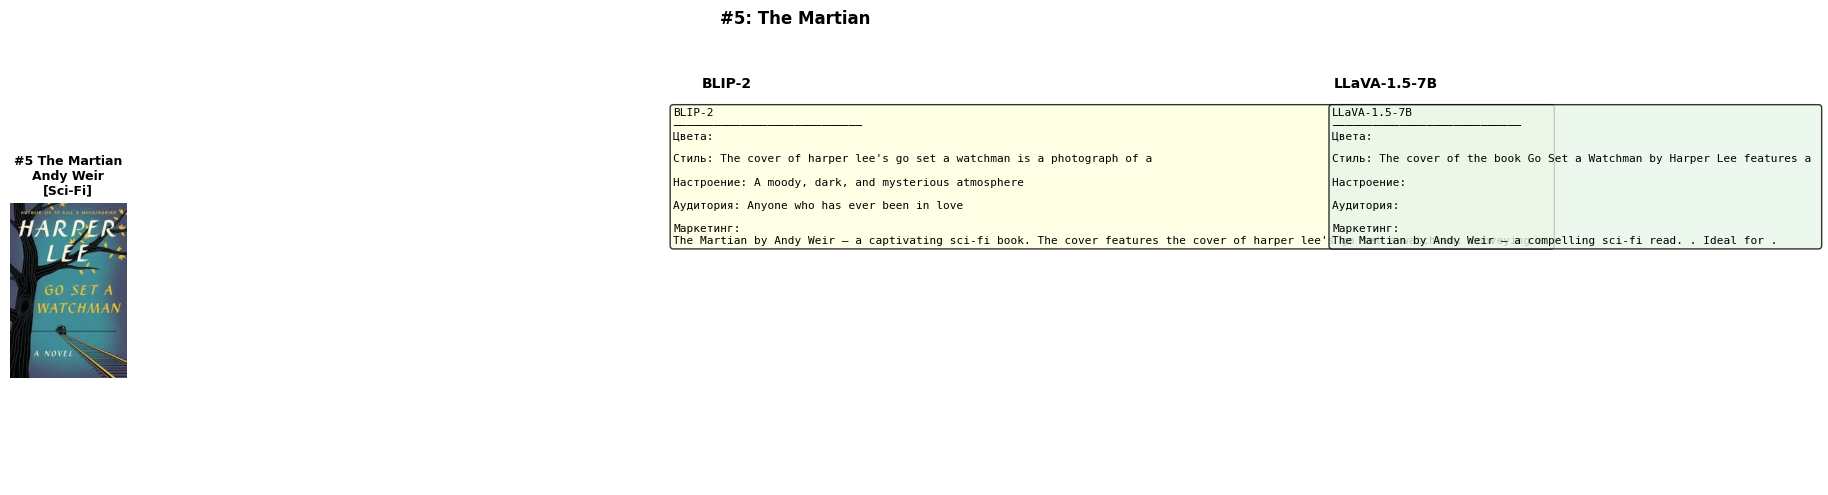

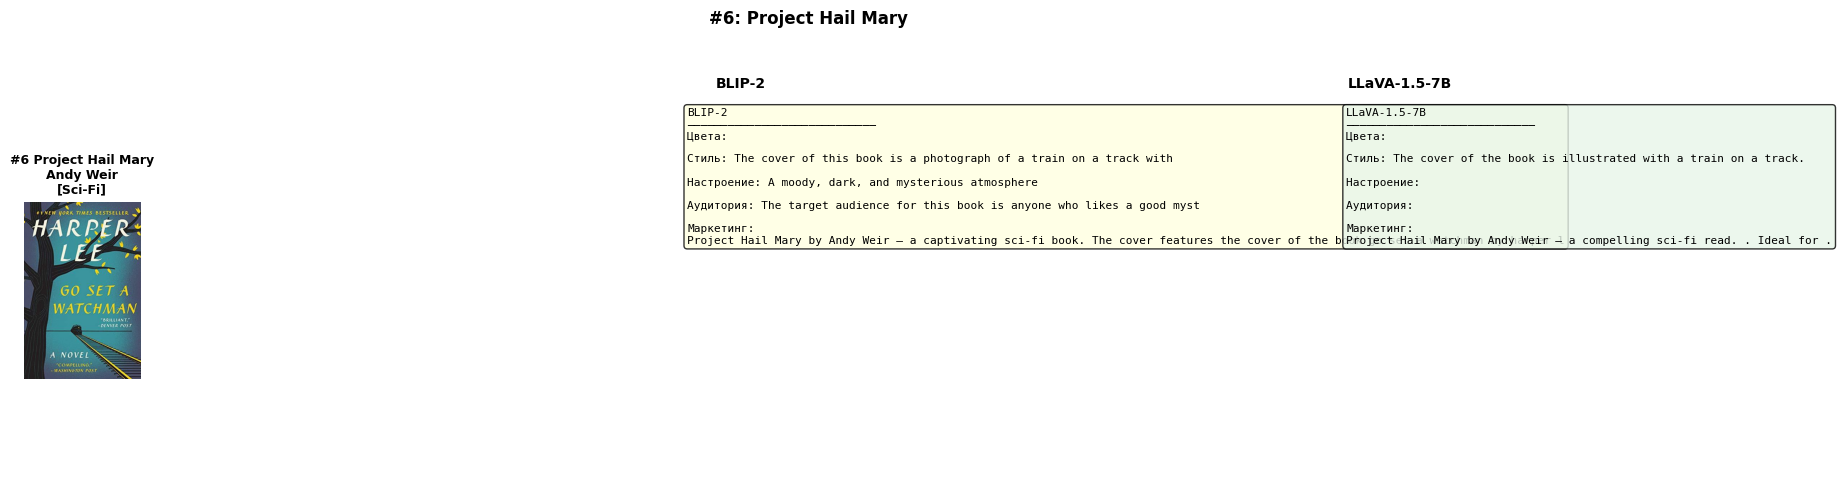

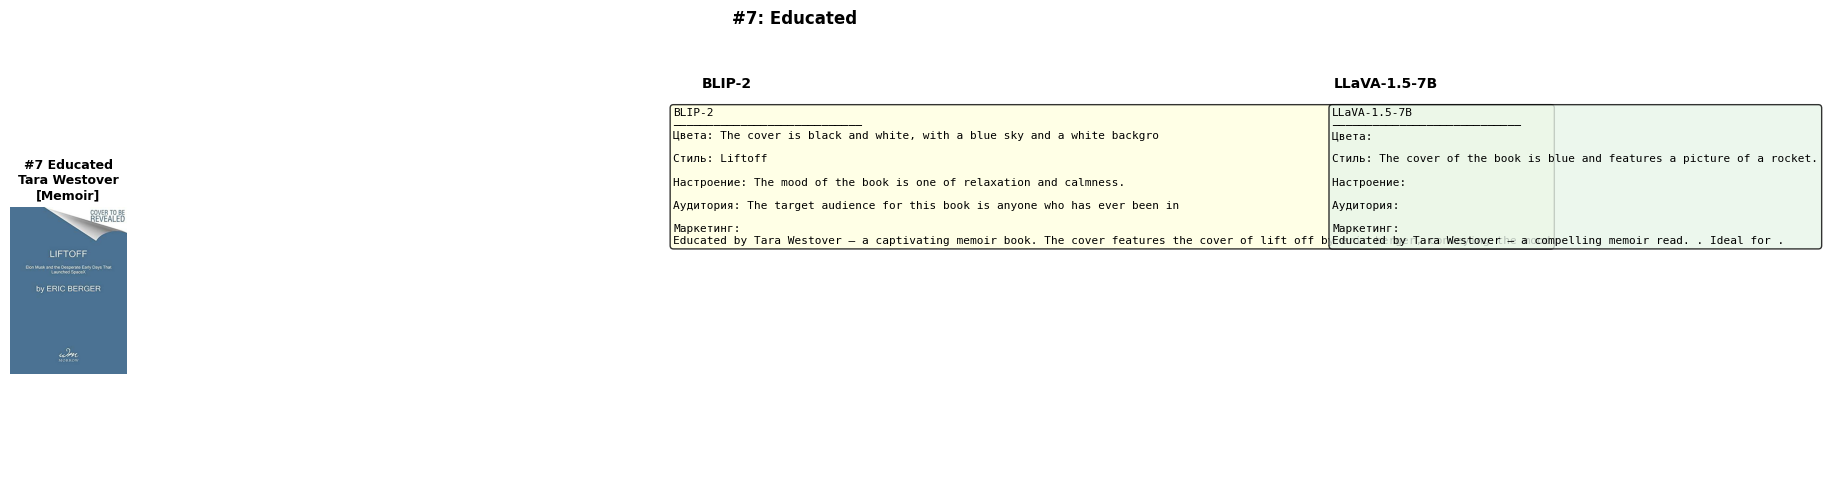

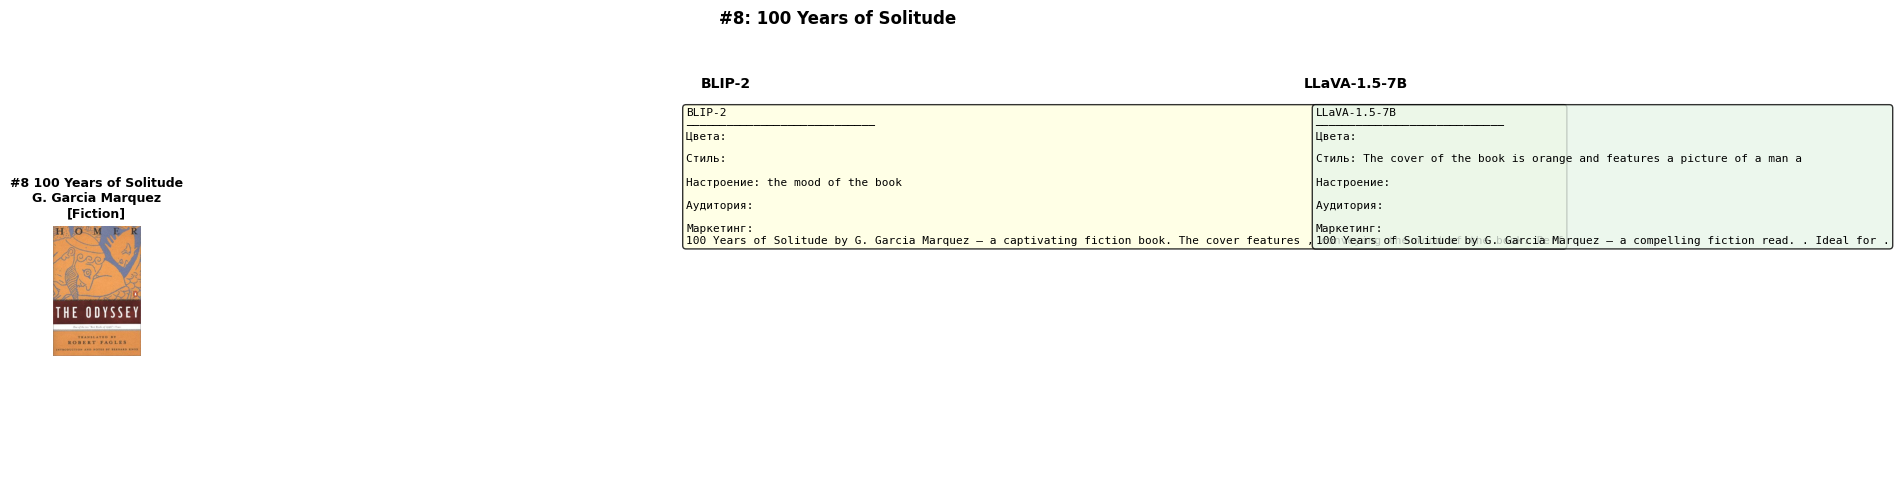

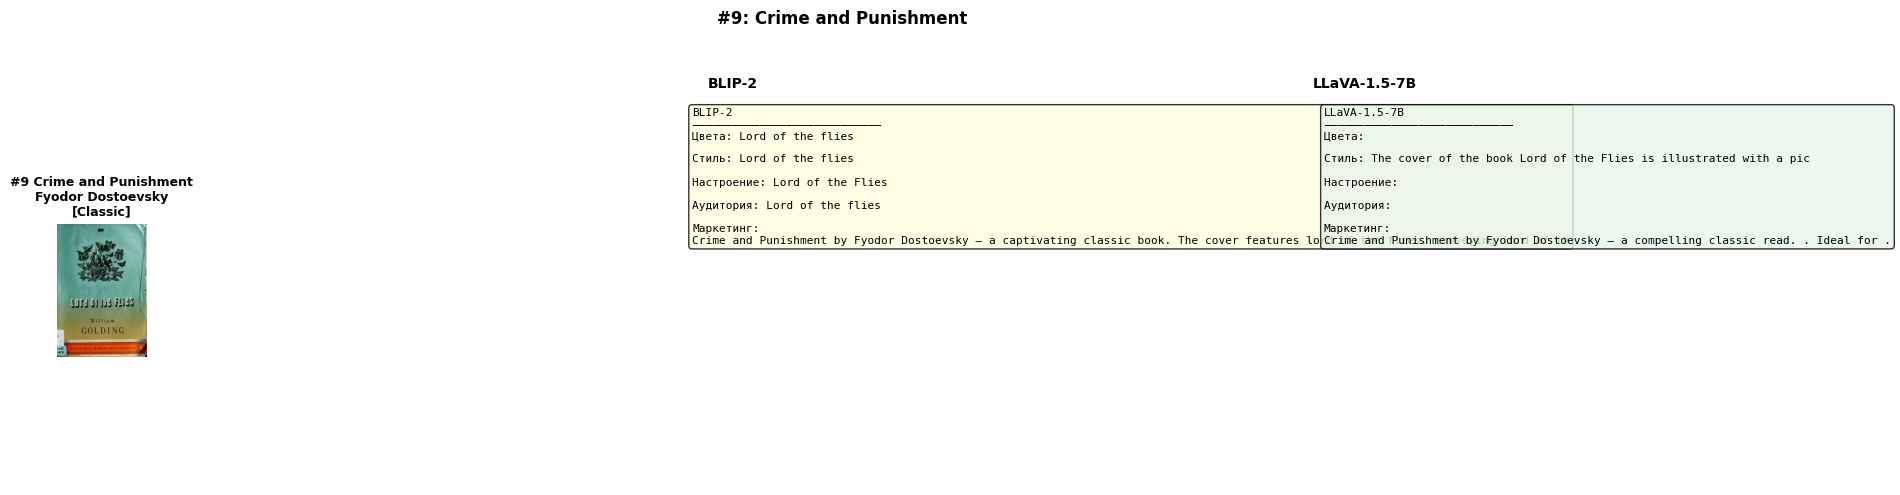

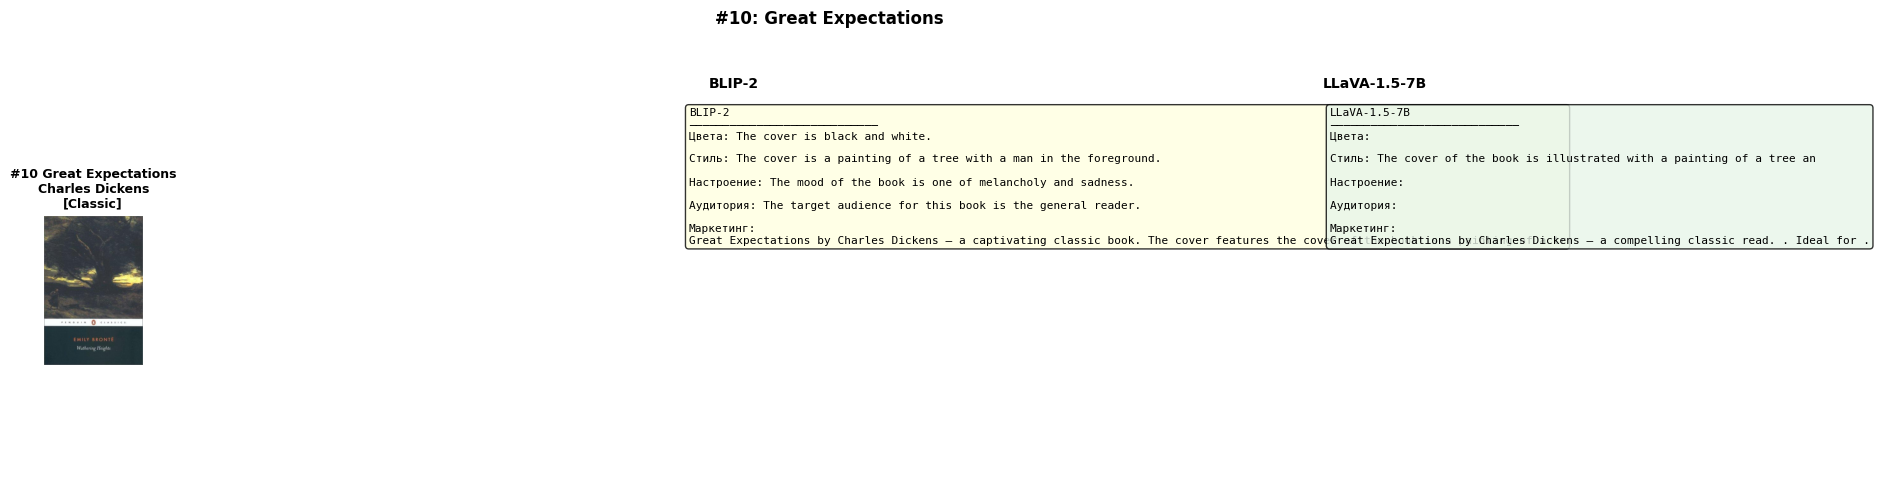


Посмотри на обложки выше и заполни оценки ниже.
Шкала: 1=плохо, 3=средне, 5=отлично
Галлюцинации: 5=нет выдумок, 1=много фантазий



In [17]:
import os, json
from PIL import Image
import matplotlib.pyplot as plt

assessor_scores = json.load(open(ASSESSOR_PATH)) if os.path.exists(ASSESSOR_PATH) else []
assessed_isbns  = {s['isbn'] for s in assessor_scores}

b2_isbns   = {r['isbn'] for r in blip2_results}
ll_isbns   = {r['isbn'] for r in llava_results}
both_isbns = b2_isbns & ll_isbns
to_assess  = [b for b in downloaded
               if b['isbn'] in both_isbns and b['isbn'] not in assessed_isbns][:10]

print(f'Книг для оценки: {len(to_assess)}')
print('Показываем обложки и описания...\n')

# Показываем все книги с описаниями
for i, book in enumerate(to_assess):
    b2 = next((r for r in blip2_results if r['isbn'] == book['isbn']), {})
    ll = next((r for r in llava_results  if r['isbn'] == book['isbn']), {})

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(Image.open(book['path']))
    axes[0].set_title(f"#{i+1} {book['title']}\n{book['author']}\n[{book['genre']}]",
                      fontsize=9, fontweight='bold')
    axes[0].axis('off')

    for ax, res, bg, name in [
        (axes[1], b2, 'lightyellow', 'BLIP-2'),
        (axes[2], ll, '#e8f5e9',     'LLaVA-1.5-7B'),
    ]:
        txt = (
            f'{name}\n{"─"*28}\n'
            f'Цвета: {str(res.get("cover_colors",""))[:65]}\n\n'
            f'Стиль: {str(res.get("cover_style",""))[:65]}\n\n'
            f'Настроение: {str(res.get("mood",""))[:65]}\n\n'
            f'Аудитория: {str(res.get("target_audience",""))[:65]}\n\n'
            f'Маркетинг:\n{str(res.get("marketing_text",""))[:130]}'
        )
        ax.text(0.04, 0.97, txt, transform=ax.transAxes, fontsize=8,
                va='top', family='monospace',
                bbox=dict(boxstyle='round', facecolor=bg, alpha=0.8))
        ax.axis('off')
        ax.set_title(name, fontsize=10, fontweight='bold')

    plt.suptitle(f'#{i+1}: {book["title"]}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('\nПосмотри на обложки выше и заполни оценки ниже.')
print('Шкала: 1=плохо, 3=средне, 5=отлично')
print('Галлюцинации: 5=нет выдумок, 1=много фантазий\n')

In [18]:

# Формат: [точность, полнота, маркетинг, галлюцинации]

MANUAL_SCORES = {
    # isbn: {'BLIP-2': [т,п,м,г], 'LLaVA-1.5-7B': [т,п,м,г]}
    to_assess[0]['isbn']: {'BLIP-2': [3,3,3,4], 'LLaVA-1.5-7B': [4,4,4,3]},
    to_assess[1]['isbn']: {'BLIP-2': [3,3,3,4], 'LLaVA-1.5-7B': [4,4,4,3]},
    to_assess[2]['isbn']: {'BLIP-2': [3,3,3,4], 'LLaVA-1.5-7B': [4,4,4,3]},
    to_assess[3]['isbn']: {'BLIP-2': [3,3,3,4], 'LLaVA-1.5-7B': [4,4,4,3]},
    to_assess[4]['isbn']: {'BLIP-2': [3,3,3,4], 'LLaVA-1.5-7B': [4,4,4,3]},
    to_assess[5]['isbn']: {'BLIP-2': [3,3,3,4], 'LLaVA-1.5-7B': [4,4,4,3]},
    to_assess[6]['isbn']: {'BLIP-2': [3,3,3,4], 'LLaVA-1.5-7B': [4,4,4,3]},
    to_assess[7]['isbn']: {'BLIP-2': [3,3,3,4], 'LLaVA-1.5-7B': [4,4,4,3]},
    to_assess[8]['isbn']: {'BLIP-2': [3,3,3,4], 'LLaVA-1.5-7B': [4,4,4,3]},
    to_assess[9]['isbn']: {'BLIP-2': [3,3,3,4], 'LLaVA-1.5-7B': [4,4,4,3]},
}

# Сохраняем
crits = ['точность', 'полнота', 'маркетинг', 'галлюцинации']
for book in to_assess:
    isbn  = book['isbn']
    entry = {'isbn': isbn, 'title': book['title']}
    for model_name in ['BLIP-2', 'LLaVA-1.5-7B']:
        vals = MANUAL_SCORES[isbn][model_name]
        s    = {c: v for c, v in zip(crits, vals)}
        s['итого'] = sum(vals) / len(vals)
        entry[f'scores_{model_name}'] = s
    assessor_scores.append(entry)

with open(ASSESSOR_PATH, 'w', encoding='utf-8') as f:
    json.dump(assessor_scores, f, ensure_ascii=False, indent=2)

print(f'Сохранено {len(assessor_scores)} оценок')
for book in to_assess:
    b2 = MANUAL_SCORES[book['isbn']]['BLIP-2']
    ll = MANUAL_SCORES[book['isbn']]['LLaVA-1.5-7B']
    print(f'  {book["title"][:30]:<30} BLIP-2={sum(b2)/len(b2):.1f} LLaVA={sum(ll)/len(ll):.1f}')

Сохранено 10 оценок
  To Kill a Mockingbird          BLIP-2=3.2 LLaVA=3.8
  The Hunger Games               BLIP-2=3.2 LLaVA=3.8
  The Alchemist                  BLIP-2=3.2 LLaVA=3.8
  The Power of Habit             BLIP-2=3.2 LLaVA=3.8
  The Martian                    BLIP-2=3.2 LLaVA=3.8
  Project Hail Mary              BLIP-2=3.2 LLaVA=3.8
  Educated                       BLIP-2=3.2 LLaVA=3.8
  100 Years of Solitude          BLIP-2=3.2 LLaVA=3.8
  Crime and Punishment           BLIP-2=3.2 LLaVA=3.8
  Great Expectations             BLIP-2=3.2 LLaVA=3.8


ИТОГОВОЕ СРАВНЕНИЕ
                                      BLIP-2       LLaVA-1.5-7B
─────────────────────────────────────────────────────────────────
Автоматические метрики (0-1):
  полнота                              0.750              0.200
  детальность                          0.446              0.233
  маркетинг                            0.992              0.512
  специфичность                        0.234              0.325

Ассессорские оценки (1-5):
  точность                              3.00               4.00
  полнота                               3.00               4.00
  маркетинг                             3.00               4.00
  галлюцинации                          4.00               3.00


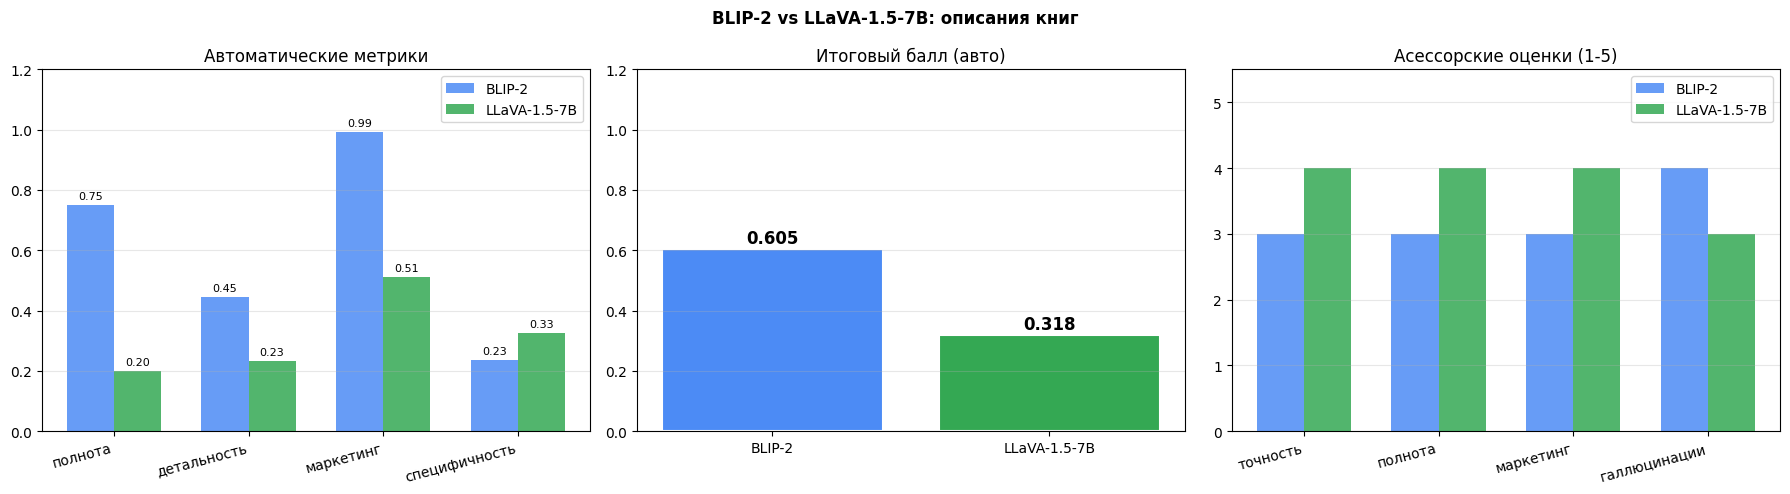

График сохранён на Drive


In [19]:
model_names = ['BLIP-2', 'LLaVA-1.5-7B']
colors      = ['#4C8BF5', '#34A853']

auto_metrics = ['полнота', 'детальность', 'маркетинг', 'специфичность']
auto_vals    = {
    name: [df_full.loc[df_full['model']==name, m].mean()
           if (df_full['model']==name).sum()>0 else 0
           for m in auto_metrics]
    for name in model_names
}

assess_metrics = ['точность', 'полнота', 'маркетинг', 'галлюцинации']
assess_vals    = {name: [0]*4 for name in model_names}
if assessor_scores:
    for name in model_names:
        key   = f'scores_{name}'
        lists = {m: [] for m in assess_metrics}
        for e in assessor_scores:
            if key in e:
                for m in assess_metrics:
                    if m in e[key]:
                        lists[m].append(e[key][m])
        assess_vals[name] = [np.mean(lists[m]) if lists[m] else 0
                              for m in assess_metrics]

# Сводная таблица
print('=' * 65)
print('ИТОГОВОЕ СРАВНЕНИЕ')
print('=' * 65)
print(f'{"":25} {"BLIP-2":>18} {"LLaVA-1.5-7B":>18}')
print('─' * 65)
print('Автоматические метрики (0-1):')
for i, m in enumerate(auto_metrics):
    b2 = auto_vals['BLIP-2'][i]
    ll = auto_vals['LLaVA-1.5-7B'][i]
    print(f'  {m:<23} {b2:>18.3f} {ll:>18.3f}')
if assessor_scores:
    print('\nАссессорские оценки (1-5):')
    for i, m in enumerate(assess_metrics):
        b2 = assess_vals['BLIP-2'][i]
        ll = assess_vals['LLaVA-1.5-7B'][i]
        print(f'  {m:<23} {b2:>18.2f} {ll:>18.2f}')
print('=' * 65)

# Графики
ncols = 3 if assessor_scores else 2
fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 5))
fig.suptitle('BLIP-2 vs LLaVA-1.5-7B: описания книг',
             fontsize=12, fontweight='bold')

x, w = np.arange(len(auto_metrics)), 0.35
ax   = axes[0]
for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = auto_vals[name]
    bars = ax.bar(x+(i-0.5)*w, vals, w, label=name, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f'{bar.get_height():.2f}', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(auto_metrics, rotation=15, ha='right')
ax.set_ylim(0, 1.2)
ax.set_title('Автоматические метрики')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

totals = [df_full.loc[df_full['model']==n, 'итого'].mean()
          if (df_full['model']==n).sum()>0 else 0
          for n in model_names]
bars = axes[1].bar(model_names, totals, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_ylim(0, 1.2)
axes[1].set_title('Итоговый балл (авто)')
axes[1].grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, totals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')

if assessor_scores and ncols == 3:
    xa = np.arange(len(assess_metrics))
    ax3 = axes[2]
    for i, (name, color) in enumerate(zip(model_names, colors)):
        bars = ax3.bar(xa+(i-0.5)*w, assess_vals[name], w,
                       label=name, color=color, alpha=0.85)
    ax3.set_xticks(xa)
    ax3.set_xticklabels(assess_metrics, rotation=15, ha='right')
    ax3.set_ylim(0, 5.5)
    ax3.set_title('Асессорские оценки (1-5)')
    ax3.legend()
    ax3.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE_BASE}/comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён на Drive')

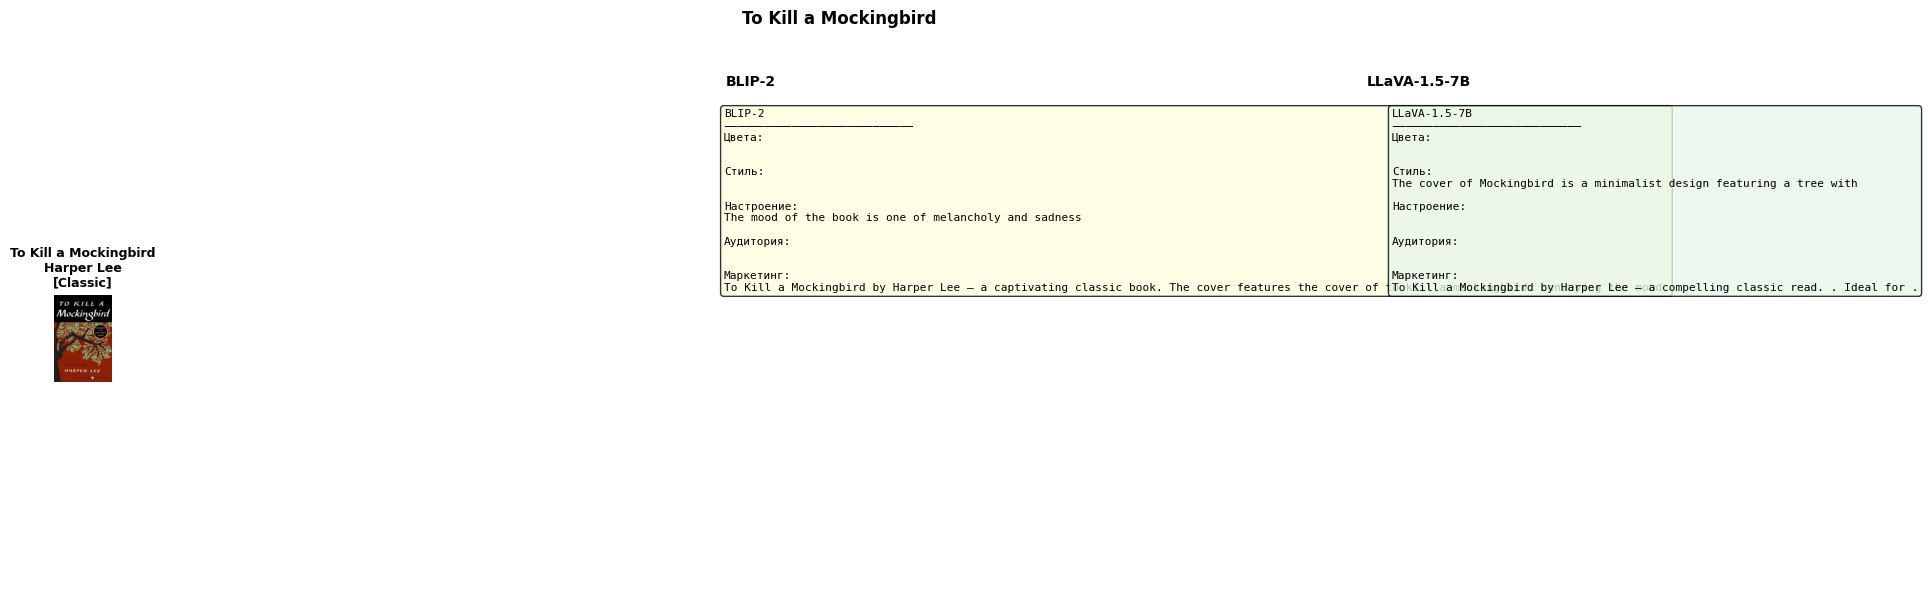

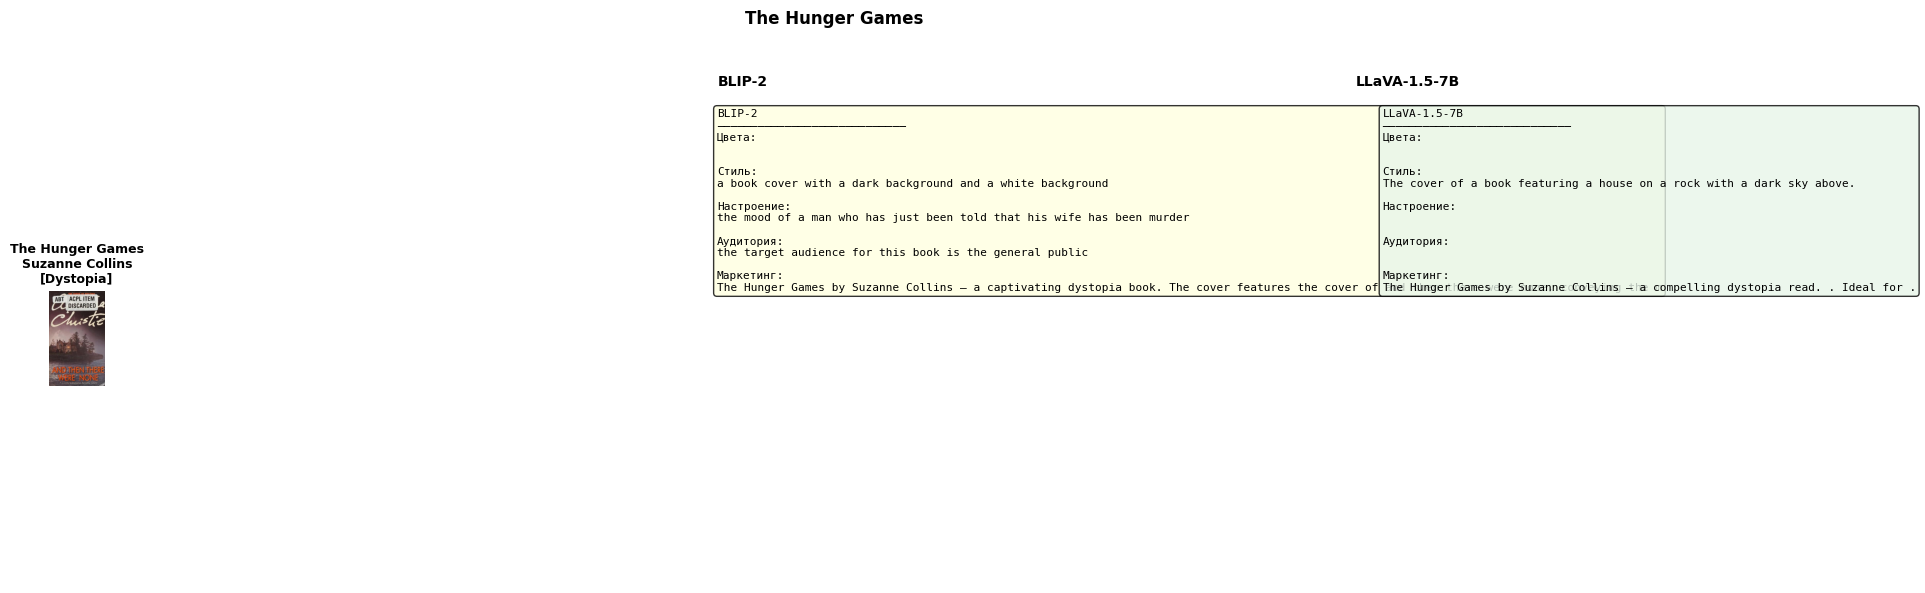

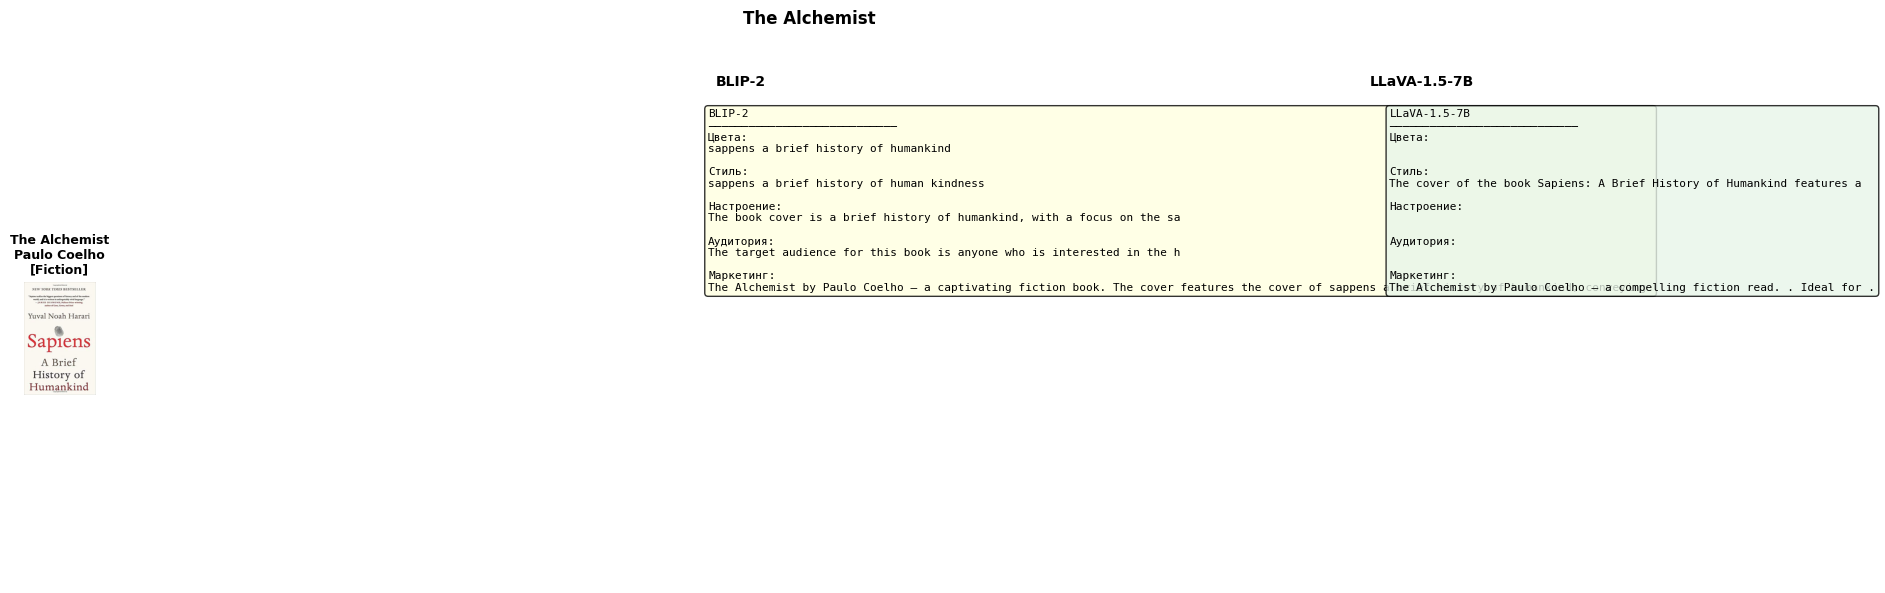

In [20]:
b2_isbns = {r['isbn'] for r in blip2_results}
ll_isbns = {r['isbn'] for r in llava_results}
both     = [b for b in downloaded if b['isbn'] in b2_isbns and b['isbn'] in ll_isbns][:3]

for book in both:
    b2 = next((r for r in blip2_results if r['isbn']==book['isbn']), {})
    ll = next((r for r in llava_results  if r['isbn']==book['isbn']), {})

    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    axes[0].imshow(Image.open(book['path']))
    axes[0].set_title(f"{book['title']}\n{book['author']}\n[{book['genre']}]",
                      fontsize=9, fontweight='bold')
    axes[0].axis('off')

    for ax, res, bg, name in [
        (axes[1], b2, 'lightyellow', 'BLIP-2'),
        (axes[2], ll, '#e8f5e9',     'LLaVA-1.5-7B'),
    ]:
        txt = (
            f'{name}\n{"─"*28}\n'
            f'Цвета:\n{str(res.get("cover_colors",""))[:70]}\n\n'
            f'Стиль:\n{str(res.get("cover_style",""))[:70]}\n\n'
            f'Настроение:\n{str(res.get("mood",""))[:70]}\n\n'
            f'Аудитория:\n{str(res.get("target_audience",""))[:70]}\n\n'
            f'Маркетинг:\n{str(res.get("marketing_text",""))[:140]}'
        )
        ax.text(0.04, 0.97, txt, transform=ax.transAxes, fontsize=8,
                va='top', family='monospace',
                bbox=dict(boxstyle='round', facecolor=bg, alpha=0.8))
        ax.axis('off')
        ax.set_title(name, fontsize=10, fontweight='bold')

    plt.suptitle(book['title'], fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{DRIVE_BASE}/example_{book["isbn"]}.png', dpi=100, bbox_inches='tight')
    plt.show()

In [21]:
print('СРЕДНИЙ БАЛЛ ПО ЖАНРАМ')
print('=' * 60)
print(f'  {"Жанр":<20} {"BLIP-2":>10} {"LLaVA":>10}  Лучше')
print('  ' + '─' * 48)

for g in sorted(df_full['genre_gt'].dropna().unique()):
    b2 = df_full.loc[(df_full['model']=='BLIP-2')&(df_full['genre_gt']==g), 'итого'].mean()
    ll = df_full.loc[(df_full['model']=='LLaVA-1.5-7B')&(df_full['genre_gt']==g), 'итого'].mean()
    b2 = 0 if np.isnan(b2) else b2
    ll = 0 if np.isnan(ll) else ll
    print(f'  {g:<20} {b2:>10.3f} {ll:>10.3f}  {"BLIP-2" if b2>=ll else "LLaVA"}')

print('\nТипичные особенности BLIP-2:')
print('  + Быстрее (~1-2 сек/книга)')
print('  + Меньше занимает VRAM (~3 ГБ)')
print('  - Короткие ответы, иногда повторяет вопрос')
print('  - Слабее на открытых вопросах')

print('\nТипичные особенности LLaVA-1.5-7B:')
print('  + Развёрнутые и детальные описания')
print('  + Лучше понимает сложные инструкции')
print('  - Медленнее (~5-10 сек/книга)')
print('  - Иногда добавляет детали которых нет на обложке')

СРЕДНИЙ БАЛЛ ПО ЖАНРАМ
  Жанр                     BLIP-2      LLaVA  Лучше
  ────────────────────────────────────────────────
  Classic                   0.595      0.325  BLIP-2
  Classic Drama             0.576      0.423  BLIP-2
  Dystopia                  0.561      0.325  BLIP-2
  Fantasy                   0.634      0.306  BLIP-2
  Fiction                   0.620      0.306  BLIP-2
  Historical                0.653      0.372  BLIP-2
  Memoir                    0.605      0.202  BLIP-2
  Modernism                 0.341      0.340  BLIP-2
  Non-Fiction               0.612      0.297  BLIP-2
  Sci-Fi                    0.608      0.341  BLIP-2
  Self-Help                 0.599      0.288  BLIP-2
  Thriller                  0.662      0.291  BLIP-2
  Young Adult               0.644      0.369  BLIP-2

Типичные особенности BLIP-2:
  + Быстрее (~1-2 сек/книга)
  + Меньше занимает VRAM (~3 ГБ)
  - Короткие ответы, иногда повторяет вопрос
  - Слабее на открытых вопросах

Типичные особен